# Q3

In [1]:
import numpy as np
from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split


### Q3.1

In [2]:
def fetch_fashion_mnist(n_samples=7000, seed=2):
    X, y = fetch_openml('Fashion-MNIST', version=1, return_X_y=True, as_frame=False)
    X = X.astype(np.float32)
    y = y.astype(str)

    rng = np.random.RandomState(seed)
    idx = rng.choice(len(X), n_samples, replace=False)
    X, y = X[idx], y[idx]

    return X, y

X, y = fetch_fashion_mnist()
print(X.shape, y.shape)


(7000, 784) (7000,)


### Q3.2

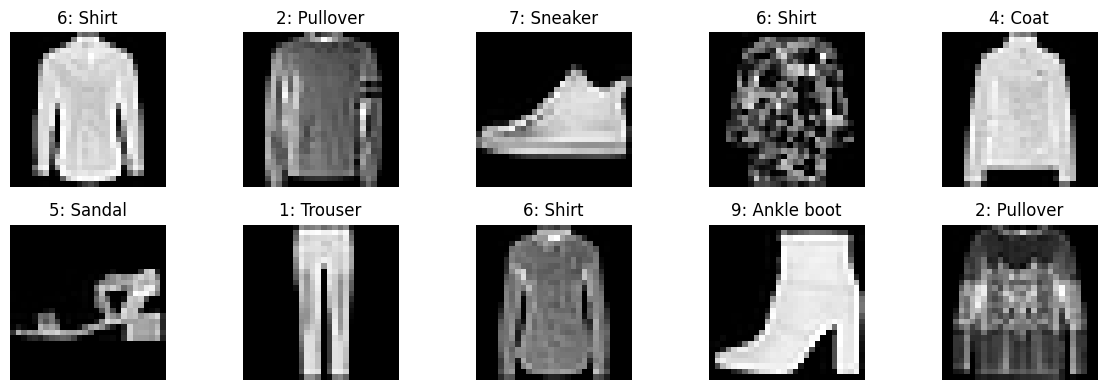

In [3]:
idx2class = {
    '0': 'T-shirt/top',
    '1': 'Trouser',
    '2': 'Pullover',
    '3': 'Dress',
    '4': 'Coat',
    '5': 'Sandal',
    '6': 'Shirt',
    '7': 'Sneaker',
    '8': 'Bag',
    '9': 'Ankle boot'
}
plt.figure(figsize=(12, 4))
for i in range(10):
    img = X[i].reshape(28, 28)
    plt.subplot(2, 5, i+1)
    plt.imshow(img, cmap='gray')
    plt.title(f"{y[i]}: {idx2class[y[i]]}")
    plt.axis('off')

plt.tight_layout()
plt.show()


### Q3.3

In [4]:
#From HW3
def cross_validation_error(X, y, model, k_folds):
    """
    Performs k-fold cross validation and returns the average
    training and validation error.
    """
    train_err_list = []
    val_err_list = []
    # Shuffle data indices and split into folds
    indices = np.random.permutation(X.shape[0])
    split_folds = np.array_split(indices, k_folds)
    for k in range(k_folds):
        val_idx = split_folds[k]
        train_idx = np.setdiff1d(indices, val_idx)
        # Build train and validation sets
        X_tr, y_tr = X[train_idx], y[train_idx]
        X_va, y_va = X[val_idx], y[val_idx]
        # Train model
        model.fit(X_tr, y_tr)
        # Predictions
        y_tr_pred = model.predict(X_tr)
        y_va_pred = model.predict(X_va)
        # Compute error rates (1 - accuracy)
        train_error = 1 - np.mean(y_tr_pred == y_tr)
        val_error = 1 - np.mean(y_va_pred == y_va)
        # Save results
        train_err_list.append(train_error)
        val_err_list.append(val_error)

    # Average results
    avg_train_error = np.mean(train_err_list)
    avg_val_error = np.mean(val_err_list)

    return avg_train_error, avg_val_error


In [5]:
def SVM_results(X_train, y_train, X_test, y_test):
    results = {}
    folds = 4

    # 1) Linear SVM with default C
    linear_model = SVC(kernel='linear')  # C is default (1.0)
    avg_train_err, avg_val_err = cross_validation_error(X_train, y_train, linear_model, folds)
    linear_model.fit(X_train, y_train)
    test_err = 1 - np.mean(linear_model.predict(X_test) == y_test)
    results['linear_SVM'] = (avg_train_err, avg_val_err, test_err)

    # 2) Polynomial kernel
    for d in [8, 6, 4, 2]:
        poly_model = SVC(kernel='poly', degree=d)
        avg_train_err, avg_val_err = cross_validation_error(X_train, y_train, poly_model, folds)
        poly_model.fit(X_train, y_train)
        test_err = 1 - np.mean(poly_model.predict(X_test) == y_test)
        results[f'{d}_poly_SVM'] = (avg_train_err, avg_val_err, test_err)

    # 3) RBF kernel
    for gamma in [10, 1.0, 0.1, 0.01, 0.001]:
        rbf_model = SVC(kernel='rbf', gamma=gamma)
        avg_train_err, avg_val_err = cross_validation_error(X_train, y_train, rbf_model, folds)
        rbf_model.fit(X_train, y_train)
        test_err = 1 - np.mean(rbf_model.predict(X_test) == y_test)
        results[f'{gamma}_rbf_SVM'] = (avg_train_err, avg_val_err, test_err)

    return results


### Q3.4

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25,random_state=42)
results = SVM_results(X_train, y_train, X_test, y_test)

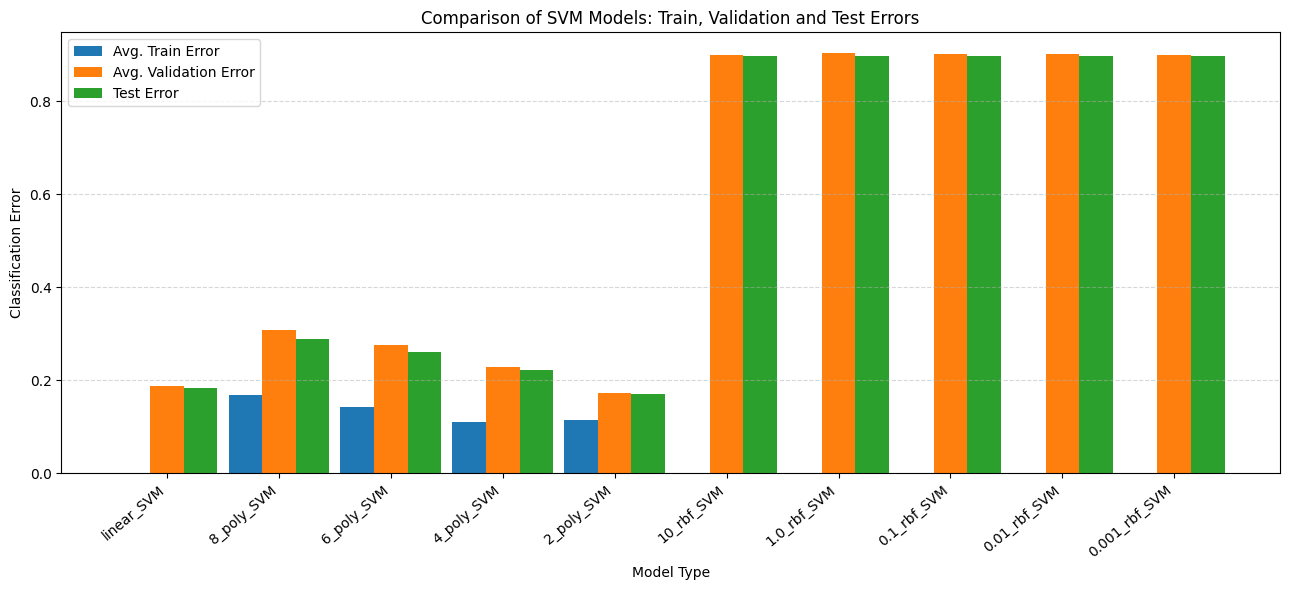

In [7]:
# Extract model names and corresponding errors
models = list(results.keys())

train_err = []
val_err = []
test_err = []

for vals in results.values():
    train_err.append(vals[0])
    val_err.append(vals[1])
    test_err.append(vals[2])

indices = np.arange(len(models))
bar_width = 0.3

plt.figure(figsize=(13, 6))

plt.bar(indices - bar_width, train_err, width=bar_width, label='Avg. Train Error')
plt.bar(indices,             val_err,   width=bar_width, label='Avg. Validation Error')
plt.bar(indices + bar_width, test_err,  width=bar_width, label='Test Error')

plt.xlabel('Model Type')
plt.ylabel('Classification Error')
plt.title('Comparison of SVM Models: Train, Validation and Test Errors')

plt.xticks(indices, models, rotation=40, ha='right')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


Based on the cross-validation results, the best-performing model is the degree-2 polynomial SVM. It achieves the lowest average training and validation errors and also performs best on the test set, which suggests that it generalizes well to new data.